In [3]:
import braincoder
import os.path as op
import pandas as pd
import nibabel as nib
import numpy as np
from nilearn import datasets

In [4]:
import sys
from braincoder.models import VonMisesPRF
from braincoder.optimize import WeightFitter, ResidualFitter
from braincoder.utils import get_rsq
import os
import os.path as op
import pandas as pd
import nibabel as nib
import numpy as np
import seaborn as sns
from nilearn.maskers import NiftiMasker
from nilearn import plotting, datasets
import glob
import argparse
from nilearn.image import math_img
from sklearn.model_selection import KFold

In [83]:
subject = 1

data_folder = '/mnt/d/data'
fn2 = op.join(
    data_folder,
    "sourcedata",
    "behavior",
    f"{subject:02d}",
    f"participant{subject:02d}_savedValues.csv",
)

stimulus_info = (
        pd.read_csv(
            fn2,
            usecols=["trialNumber", "runNumber", "visual"],
        )
        .rename(columns={"trialNumber": "trial_nr", "runNumber": "run"})
        .set_index(['run', 'trial_nr'])
        .sort_index()
    )
mapping = [22.5 * np.pi / 180, 67.5 * np.pi / 180, 112.5 * np.pi / 180]
mapping = np.array(mapping) * 2
stimulus_info['visual'] = stimulus_info['visual'].map(lambda x: mapping[x])
bids_folder = "/mnt/d/data/ds-mlearn"
derivatives = op.join(bids_folder, "derivatives")
base_dir = "glmsingle"
base_dir = op.join(derivatives, base_dir, f"sub-{subject:02d}", "func")
betas = nib.load(op.join(base_dir, f"sub-{subject:02d}_task-task_space-T1w_desc-visualstim.nii.gz"))
brain_mask = nib.load(op.join(derivatives,"fmriprep",f"sub-{subject:02d}", "func", f"sub-{subject:02d}_task-learn_run-1_space-T1w_desc-brain_mask.nii.gz"))
t1w = nib.load(op.join(derivatives,"fmriprep",f"sub-{subject:02d}", "anat", f"sub-{subject:02d}_desc-preproc_T1w.nii.gz"))
vis_mask = nib.load(op.join(derivatives,'encoding_model',f'sub-{subject:02d}','anat', f'sub-{subject:02d}_surf2img_v1.nii.gz'))

In [84]:
stimulus_info['visual'].value_counts()

visual
0.785398    120
2.356194    120
3.926991    120
Name: count, dtype: int64

In [85]:
from nilearn.maskers import NiftiMasker

In [86]:
vis_mask = math_img('img == 1', img=vis_mask)

In [87]:
vis_mask.get_fdata()[vis_mask.get_fdata() == 1].shape

(455,)

In [88]:
masker = NiftiMasker(vis_mask)

data = masker.fit_transform(betas)

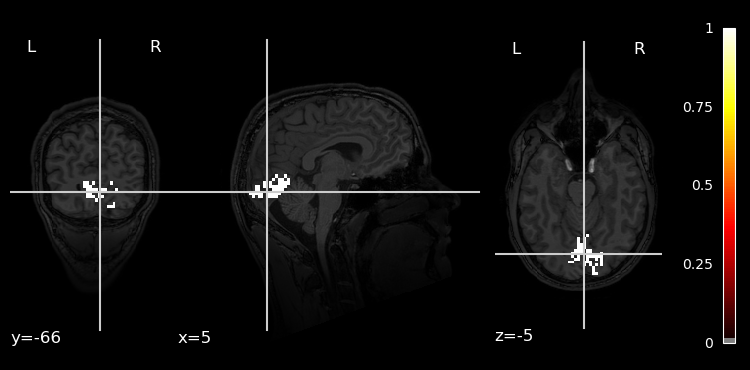

In [34]:
plotting.plot_stat_map(vis_mask, t1w, threshold=0.02)

In [89]:
parameters = pd.DataFrame({'mu': [0.0, 0.5 * np.pi, 1 * np.pi, 1.5 * np.pi]})
parameters['amplitude'] = 1
parameters['kappa'] = 1.
parameters['baseline'] = 0.0

In [90]:
paradigm = stimulus_info['visual'].astype(np.float32)

In [91]:
stimulus_info['visual']

run  trial_nr
1    1           0.785398
     2           2.356194
     3           3.926991
     4           0.785398
     5           3.926991
                   ...   
6    56          0.785398
     57          3.926991
     58          2.356194
     59          3.926991
     60          0.785398
Name: visual, Length: 360, dtype: float64

In [92]:
def wrap_angle(x):
    return np.mod(x + np.pi, 2*np.pi) - np.pi

def to_complex(x):
    return np.exp(1j*x)

def from_complex(x):
    x = np.angle(x)
    return np.where(x < 0, x + 2*np.pi, x)

def get_posterior_stats(posterior, ground_truth=None):
    posterior = posterior.copy()
    complex_grid = np.asarray(to_complex(posterior.columns))

    # Take integral over the posterior to get to the expectation (mean posterior)
    # In this case a complex number that we convert back to an angle between 0 and 2pi
    E = from_complex(np.trapz(posterior*complex_grid[np.newaxis,:], axis=1))

    # Take the integral over the posterior to get the expectation of the distance to the
    # mean posterior (i.e., standard deviation)
    relative_error = E[:, np.newaxis] - posterior.columns.values[np.newaxis,:]

    # Wrap the angle to be between 0 and pi, the error can never be larger than pi (180 degrees)
    relative_error = wrap_angle(relative_error)
    absolute_error = np.abs(relative_error)
    sd = np.trapz(absolute_error * posterior, posterior.columns, axis=1)

    stats = pd.DataFrame({'E':E, 'sd':sd}, index=posterior.index)

    if ground_truth is not None:
        stats['E_error'] = wrap_angle(stats['E'] - ground_truth)
        stats['E_error_abs'] = np.abs(stats['E_error'])
        stats['ground_truth'] = ground_truth

    return stats

In [118]:
parameters = parameters.astype(np.float32)

data_columns = ['voxel_'+str(idx) for idx in range(1,data.shape[1]+1)]
data = pd.DataFrame(data, columns=data_columns, index=pd.Index(np.arange(len(data)), name='frame')).astype(np.float32)
paradigm = stimulus_info["visual"].astype(np.float32).to_frame()
paradigm.index = data.index

kfold = KFold(n_splits=6)
rsq = []
posteriors = []
posterior_stats = []

In [119]:
for i, (train,test) in enumerate(kfold.split(data)):
    train_data = data.loc[train,:]
    test_data = data.loc[test,:]
    model = VonMisesPRF(parameters=parameters, paradigm=paradigm.loc[train].astype(np.float32))
    fitter = WeightFitter(model=model, paradigm=paradigm.loc[train].astype(np.float32), parameters=parameters, data=train_data)
    weights = pd.DataFrame(fitter.fit(1.0).numpy().astype(np.float32), columns=data_columns, index=parameters.index)
    pred = model.predict(paradigm=paradigm.loc[test].astype(np.float32), weights=weights).astype(np.float32)
    r2 = get_rsq(test_data, pred)
    rsq.append(r2)
    best_100 = r2.sort_values(ascending=False).index[:100]
    train_best100 = train_data.loc[:,best_100].astype(np.float32)
    test_best100 = test_data.loc[:,best_100].astype(np.float32)
    truth = stimulus_info['visual'].values[test].astype(np.float32)
    resid_fitter = ResidualFitter(model, train_best100, paradigm=paradigm.loc[train],
                                    parameters=parameters, weights=weights.loc[:,best_100])
    omega, dof = resid_fitter.fit()
    stimulus_range = np.linspace(0,2*np.pi,100) # posterior + posterior_stats
    posterior = model.get_stimulus_pdf(test_best100, mapping.astype(np.float32), model.parameters, omega=omega, dof=dof)
    posterior_stat = get_posterior_stats(posterior, ground_truth=truth)
    posterior_pupil_range = model.get_stimulus_pdf(test_best100, stimulus_range.astype(np.float32), model.parameters, omega=omega, dof=1.)
    posterior_pupil_range_stat = get_posterior_stats(posterior_pupil_range, ground_truth=truth)
    posterior['prediction'] = mapping[np.argmax(posterior,axis=1)]
    posterior['truth'] = truth
    posterior_stat = posterior_stat.join(posterior_pupil_range_stat, lsuffix='', rsuffix='_full_range')
    posteriors.append(posterior)
    posterior_stats.append(posterior_stat)

mean_r2 = np.nanmean(np.array(rsq),axis=0)
r2_img = masker.inverse_transform(mean_r2)

posteriors = pd.concat(posteriors, keys=np.arange(1,7), names=['run'])
posterior_stats = pd.concat(posterior_stats, keys=np.arange(1,7), names=['run'])
print(posterior_stats)
print(posterior)

uncertainty = posterior_stats[['E_error_abs', 'sd']].corr().values[0,1]
posteriors['correct'] = posteriors['prediction'] == posteriors['truth']
accuracy = posteriors['correct'].mean()

print('Accuracy:', accuracy)
print('Decoded uncertainty:', uncertainty)

init_tau: 0.4034979045391083, 5.763664722442627
WWT max: 20.259912490844727


  0%|          | 0/1000 [00:00<?, ?it/s]

2024-02-28 16:32:53.102578: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/PartitionedCall_grad/PartitionedCall_8' with dtype int32 and shape [2]
	 [[{{node gradients/PartitionedCall_grad/PartitionedCall_8}}]]
2024-02-28 16:32:53.216593: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MultivariateNormalTriL_1/log_prob/MultivariateNormalTriL_chain_of_MultivariateNormalTriL_shift_of_MultivariateNormalTriL_scale_matvec_linear_operator_2/inverse_log_det_jacobian/MultivariateNormalTriL_scale_matvec_linear_operator_1/inverse_log_det_jacobian/LinearOperatorLowerTriangular/log_abs_det/diag_part_grad/diag/M

stimulus      0.785398      2.356194      3.926991
frame                                             
0         0.000000e+00  0.000000e+00  0.000000e+00
1         0.000000e+00  0.000000e+00  0.000000e+00
2         2.802597e-45  2.802597e-45  1.681558e-44
3         0.000000e+00  0.000000e+00  0.000000e+00
4         0.000000e+00  0.000000e+00  0.000000e+00
5         0.000000e+00  0.000000e+00  0.000000e+00
6         0.000000e+00  0.000000e+00  0.000000e+00
7         0.000000e+00  0.000000e+00  0.000000e+00
8         0.000000e+00  0.000000e+00  0.000000e+00
9         0.000000e+00  0.000000e+00  1.401298e-45
10        0.000000e+00  0.000000e+00  0.000000e+00
11        0.000000e+00  0.000000e+00  0.000000e+00
12        0.000000e+00  0.000000e+00  0.000000e+00
13        0.000000e+00  0.000000e+00  0.000000e+00
14        0.000000e+00  0.000000e+00  0.000000e+00
15        0.000000e+00  0.000000e+00  0.000000e+00
16        0.000000e+00  0.000000e+00  0.000000e+00
17        0.000000e+00  0.00000

  0%|          | 0/1000 [00:00<?, ?it/s]

...

2024-02-28 16:33:12.335771: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/PartitionedCall_grad/PartitionedCall_8' with dtype int32 and shape [2]
	 [[{{node gradients/PartitionedCall_grad/PartitionedCall_8}}]]
2024-02-28 16:33:12.422728: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MultivariateNormalTriL_1/log_prob/MultivariateNormalTriL_chain_of_MultivariateNormalTriL_shift_of_MultivariateNormalTriL_scale_matvec_linear_operator_2/inverse_log_det_jacobian/MultivariateNormalTriL_scale_matvec_linear_operator_1/inverse_log_det_jacobian/LinearOperatorLowerTriangular/log_abs_det/diag_part_grad/diag/M

stimulus  0.785398  2.356194  3.926991
frame                                 
240            0.0       0.0       0.0
241            0.0       0.0       0.0
242            0.0       0.0       0.0
243            0.0       0.0       0.0
244            0.0       0.0       0.0
245            0.0       0.0       0.0
246            0.0       0.0       0.0
247            0.0       0.0       0.0
248            0.0       0.0       0.0
249            0.0       0.0       0.0
250            0.0       0.0       0.0
251            0.0       0.0       0.0
252            0.0       0.0       0.0
253            0.0       0.0       0.0
254            0.0       0.0       0.0
255            0.0       0.0       0.0
256            0.0       0.0       0.0
257            0.0       0.0       0.0
258            0.0       0.0       0.0
259            0.0       0.0       0.0
260            0.0       0.0       0.0
261            0.0       0.0       0.0
262            0.0       0.0       0.0
263            0.0       

  0%|          | 0/1000 [00:00<?, ?it/s]

2024-02-28 16:33:18.494512: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/PartitionedCall_grad/PartitionedCall_8' with dtype int32 and shape [2]
	 [[{{node gradients/PartitionedCall_grad/PartitionedCall_8}}]]
2024-02-28 16:33:18.625631: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MultivariateNormalTriL_1/log_prob/MultivariateNormalTriL_chain_of_MultivariateNormalTriL_shift_of_MultivariateNormalTriL_scale_matvec_linear_operator_2/inverse_log_det_jacobian/MultivariateNormalTriL_scale_matvec_linear_operator_1/inverse_log_det_jacobian/LinearOperatorLowerTriangular/log_abs_det/diag_part_grad/diag/M

KeyboardInterrupt: 

In [31]:
posteriors = pd.concat(posteriors, keys=np.arange(1,7), names=['run'])
posterior_stats = pd.concat(posterior_stats, keys=np.arange(1,7), names=['run'])

In [32]:
posterior_stats[['E_error_abs', 'sd']].corr().values[0,1]

0.16194321914590384

In [33]:
posteriors['correct'] = posteriors['prediction'] == posteriors['truth']
postcorrelation_matrix = pd.crosstab(posteriors['prediction'], posteriors['truth'])

In [34]:
posteriors['correct'].mean()

0.5361111111111111

In [35]:
post1correlation_matrix.to_numpy()

NameError: name 'post1correlation_matrix' is not defined

In [36]:
from braincoder.utils import get_rsq
pred = model.predict(weights=weights)

r2 = get_rsq(data, pred.values)

(300, 407)


ValueError: operands could not be broadcast together with shapes (360,407) (300,407) 

In [5]:
import seaborn as sns

/tmp/ipykernel_994/2099611227.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  r2_plot = sns.distplot(rsq)
/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_cont

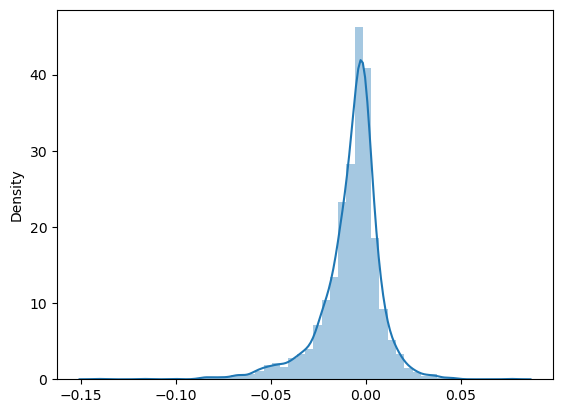

In [61]:
r2_plot = sns.distplot(rsq)

In [130]:
np.mean(r2)

0.004079879

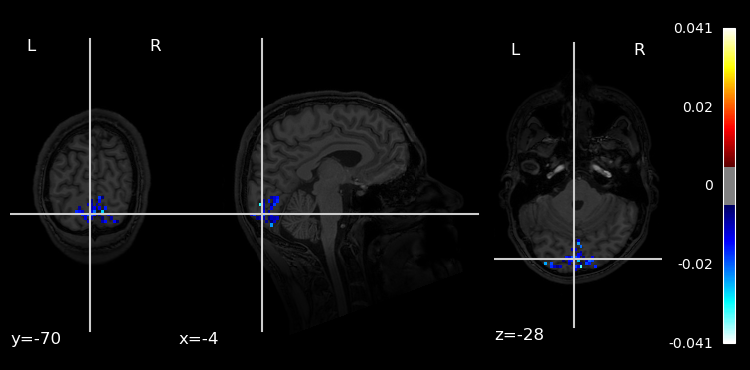

In [180]:
r2_img = masker.inverse_transform(mean_r2)

from nilearn import plotting
import os

plotting.plot_stat_map(r2_img, t1w, threshold=0.005)

target_dir = op.join(bids_folder, 'derivatives', 'encoding_model', f'sub-{subject:02d}', 'func')

if not op.exists(target_dir):
    os.makedirs(target_dir)

#r2_img.to_filename(op.join(target_dir, f'sub-{subject:02d}_desc-r2_pars.nii.gz'))

In [5]:
subjects = range(1,65)
accuracy = list()
for subject in subjects:
    if subject not in [8, 13, 16, 31, 32, 44]:
        stats_dir = op.join(bids_folder, "derivatives", "encoding_model", f"sub-{subject:02d}", "stats")
        summary_stats = np.load(op.join(stats_dir, f"sub-{subject:02d}_space-T1w_visual_summary_stats.npy"))
        print(f"Subject {subject:02d}: accuray = {summary_stats[0]:.2f}, uncertainty = {summary_stats[1]:.2f}")
        accuracy.append(summary_stats[0])
np.mean(accuracy)

Subject 01: accuray = 0.56, uncertainty = 0.30
Subject 02: accuray = 0.54, uncertainty = 0.16
Subject 03: accuray = 0.52, uncertainty = 0.31
Subject 04: accuray = 0.52, uncertainty = 0.35
Subject 05: accuray = 0.49, uncertainty = 0.26
Subject 06: accuray = 0.48, uncertainty = 0.23
Subject 07: accuray = 0.49, uncertainty = 0.24
Subject 09: accuray = 0.52, uncertainty = 0.23
Subject 10: accuray = 0.52, uncertainty = 0.28
Subject 11: accuray = 0.53, uncertainty = 0.21
Subject 12: accuray = 0.47, uncertainty = 0.16
Subject 14: accuray = 0.56, uncertainty = 0.31
Subject 15: accuray = 0.52, uncertainty = 0.29
Subject 17: accuray = 0.51, uncertainty = 0.25
Subject 18: accuray = 0.53, uncertainty = 0.30
Subject 19: accuray = 0.58, uncertainty = 0.23
Subject 20: accuray = 0.51, uncertainty = 0.20
Subject 21: accuray = 0.54, uncertainty = 0.35
Subject 22: accuray = 0.54, uncertainty = 0.32
Subject 23: accuray = 0.53, uncertainty = 0.28
Subject 24: accuray = 0.52, uncertainty = 0.24
Subject 25: a

0.5334291187739464

In [70]:
import statsmodels.formula.api as sm

In [48]:
subjects = range(1,65)
combined_df = []
for subject in subjects:
    if subject not in [8, 13, 16, 31, 32, 44]:
        fn3 = f'/mnt/d/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-{subject:02d}/'
        spe = np.load(op.join(fn3, 'spe.npy'))
        rpe = np.load(op.join(fn3, 'rpeBestOverall.npy'))
        stats_dir = op.join(bids_folder, "derivatives", "encoding_model", f"sub-{subject:02d}", "stats")
        posterior_stats = pd.read_csv(op.join(stats_dir, f"sub-{subject:02d}_space-T1w_visual_posterior_stats.csv"))
        posterior = pd.read_csv(op.join(stats_dir, f"sub-{subject:02d}_space-T1w_visual_posterior.csv"))
        posterior_stats['spe'] = spe.flatten()
        posterior_stats['subject'] = subject
        posterior_stats['correct'] = posterior['correct']
        combined_df.append(posterior_stats)

combined_df = pd.concat(combined_df)

In [72]:
combined_df

,run,frame,E,sd,E_error,E_error_abs,ground_truth,E_full_range,sd_full_range,E_error_full_range,E_error_abs_full_range,ground_truth_full_range,spe,subject,correct
0,1,0,1.782238,0.869682,0.996840,0.996840,0.785398,1.434755,0.047315,0.649357,0.649357,0.785398,2.197225,1,True
1,1,1,2.833309,0.921426,0.477114,0.477114,2.356194,3.417619,0.069100,1.061424,1.061424,2.356194,2.302585,1,False
2,1,2,3.293689,0.895449,-0.633302,0.633302,3.926991,4.415976,0.065831,0.488985,0.488985,3.926991,2.397895,1,True
3,1,3,1.239738,0.746025,0.454339,0.454339,0.785398,0.352162,0.056460,-0.433236,0.433236,0.785398,2.484907,1,True
4,1,4,2.089274,0.921062,-1.837717,1.837717,3.926991,1.124769,0.086085,-2.802222,2.802222,3.926991,2.564949,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,6,55,1.362577,0.842638,0.577179,0.577179,0.785398,0.367616,0.061515,-0.417782,0.417782,0.785398,3.060271,64,True
356,6,56,2.678510,0.728974,0.322315,0.322315,2.356194,3.036252,0.039442,0.680057,0.680057,2.356194,1.871802,64,True
357,6,57,3.201436,0.865254,-0.725555,0.725555,3.926991,3.759816,0.058872,-0.167175,0.167175,3.926991,2.397895,64,True
358,6,58,2.299026,0.483344,-0.057169,0.057169,2.356194,2.188112,0.052879,-0.168082,0.168082,2.356194,2.258782,64,True


In [76]:
import pingouin
pingouin.rm_corr(combined_df, x='E_full_range', y='sd_full_range', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.048866,20821,1.722299e-12,"[0.04, 0.06]",1.0


In [71]:
formula = 'sd_full_range ~ spe'
model = sm.mixedlm(formula, data=combined_df, groups='subject')

model_fit = model.fit(method='bfgs')

# Print the summary of the model
print(model_fit.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sd_full_range
No. Observations: 20880   Method:             REML         
No. Groups:       58      Scale:              0.0002       
Min. group size:  360     Log-Likelihood:     58097.5282   
Max. group size:  360     Converged:          Yes          
Mean group size:  360.0                                    
------------------------------------------------------------
              Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     0.065     0.001  47.676  0.000   0.062   0.067
spe           0.000     0.000   0.361  0.718  -0.000   0.001
subject Var   0.000     0.001                               



/home/ella/anaconda3/envs/multlearn-decoding/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [3]:
import os
from nilearn import plotting
bids_folder = "/mnt/d/data/ds-mlearn"
derivatives = op.join(bids_folder, "derivatives")
encoding_dir = op.join(bids_folder, 'derivatives', 'encoding_model')
""" brain_mask = nib.load(
    op.join(
        derivatives,
        "fmriprep",
        f"sub-01",
        "func",
        "MNI152NLin2009cAsym",
        f"sub-01_task-learn_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz",
    )
) """

loaded_r2s = list()
for _,_,files in os.walk(encoding_dir):
    for file in files:
        if file.endswith('.nii.gz'):
            if 'MNI152NLin2009cAsym' in file:
                sub = file.split('_')[0]
                r2 = nib.load(op.join(encoding_dir,sub,'func', "MNI152NLin2009cAsym",file))
                func = r2
                r2 = r2.get_fdata()
                loaded_r2s.append(r2)


In [4]:
loaded_r2s = np.array(loaded_r2s)
loaded_r2s.shape

(58, 65, 77, 56)

In [5]:
mean_r2 = np.mean(loaded_r2s, axis=0)
mean_r2.shape

(65, 77, 56)

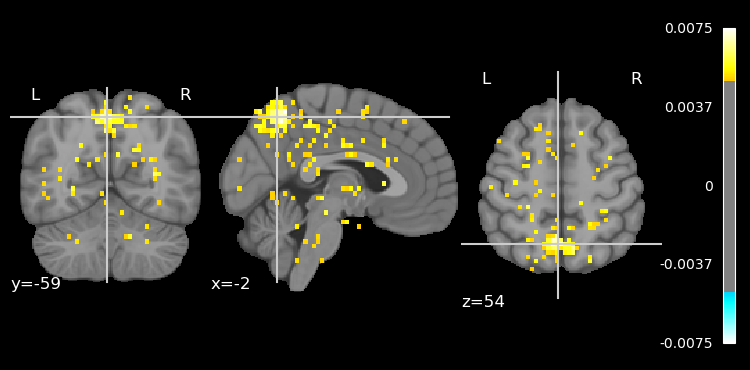

In [6]:
mean_r2_img = nib.Nifti1Image(mean_r2, func.affine)
target_dir = op.join(bids_folder, 'derivatives', 'encoding_model')
mean_r2_img.to_filename(op.join(target_dir, f'group_desc-r2_pars.nii.gz'))
anatomical_image = datasets.load_mni152_template()
plotting.plot_stat_map(mean_r2_img, anatomical_image, threshold=0.005)

In [7]:
os.walk(encoding_dir)

<generator object _walk at 0x000001F527071BA0>